# Task 3

## Answer (a)

To compute the count and percentage of VaR breaches, we need compute **10D VaR** and **forward 10D return** and compare them.

### Compute VaR

we need compute daily log return first, and the compute rolling standard deviation $\sigma$ from 21 daily returns.

$$10D\;VaR_t=Factor*\sigma_t*\sqrt{10}$$

### Compute forward 10D return
Use the daily log return data.

When we get **10D VaR** and **forward 10D return** data, we need find the days when **forward 10D return** is below **10D VaR**.

Let's start.

First, import python packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Define constants.

In [14]:
rolling_window = 21

c = 0.99
inverse_cdf = norm.ppf(1-c)
factor = inverse_cdf
print(f'Exact value of Normal ICDF for p = {1-c:.2f} is: {inverse_cdf}')

Exact value of Normal ICDF for p = 0.01 is: -2.3263478740408408


Load index data from excel.

In [4]:
data = pd.read_excel('Indices_Download_2026.xlsx', index_col='Date')
data.index = pd.to_datetime(data.index)
data

,^GSPC,^NDX
Date,,
2015-10-15,2023.859985,4418.220215
2015-10-16,2033.109985,4438.620117
2015-10-19,2033.660034,4462.069824
2015-10-20,2030.770020,4438.180176
2015-10-21,2018.939941,4413.520020
...,...,...
2026-01-26,6950.229980,25713.210938
2026-01-27,6978.600098,25939.740234
2026-01-28,6978.029785,26022.789062


Compute the 1D log-return.

In [5]:
data['LogReturn'] = np.log(data['^GSPC']) - np.log(data['^GSPC'].shift(1))
data

,^GSPC,^NDX,LogReturn
Date,,,
2015-10-15,2023.859985,4418.220215,NaN
2015-10-16,2033.109985,4438.620117,0.004560
2015-10-19,2033.660034,4462.069824,0.000271
2015-10-20,2030.770020,4438.180176,-0.001422
2015-10-21,2018.939941,4413.520020,-0.005842
...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994
2026-01-27,6978.600098,25939.740234,0.004074
2026-01-28,6978.029785,26022.789062,-0.000082


Compute forward 10D log-return.

In [6]:
data['Forward10dReturn'] = np.log(data['^GSPC'].shift(-11)) - np.log(data['^GSPC'].shift(-1))
data

,^GSPC,^NDX,LogReturn,Forward10dReturn
Date,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.022494
2015-10-16,2033.109985,4438.620117,0.004560,0.034027
2015-10-19,2033.660034,4462.069824,0.000271,0.038173
2015-10-20,2030.770020,4438.180176,-0.001422,0.040464
2015-10-21,2018.939941,4413.520020,-0.005842,0.022841
...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN
2026-01-27,6978.600098,25939.740234,0.004074,NaN
2026-01-28,6978.029785,26022.789062,-0.000082,NaN


Compute 21D rolling standard deviation.

In [7]:
data['SD'] = data['LogReturn'].rolling(rolling_window, min_periods=rolling_window).std()
data

,^GSPC,^NDX,LogReturn,Forward10dReturn,SD
Date,,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.022494,NaN
2015-10-16,2033.109985,4438.620117,0.004560,0.034027,NaN
2015-10-19,2033.660034,4462.069824,0.000271,0.038173,NaN
2015-10-20,2030.770020,4438.180176,-0.001422,0.040464,NaN
2015-10-21,2018.939941,4413.520020,-0.005842,0.022841,NaN
...,...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN,0.006622
2026-01-27,6978.600098,25939.740234,0.004074,NaN,0.006643
2026-01-28,6978.029785,26022.789062,-0.000082,NaN,0.006642


Compute VaR and Breach

In [8]:
data['VaR'] = data['SD'] * np.sqrt(10) * factor
data['Breach'] = np.where(data['Forward10dReturn'] < data['VaR'], 1, 0)
data

,^GSPC,^NDX,LogReturn,Forward10dReturn,SD,VaR,Breach
Date,,,,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.022494,NaN,NaN,0
2015-10-16,2033.109985,4438.620117,0.004560,0.034027,NaN,NaN,0
2015-10-19,2033.660034,4462.069824,0.000271,0.038173,NaN,NaN,0
2015-10-20,2030.770020,4438.180176,-0.001422,0.040464,NaN,NaN,0
2015-10-21,2018.939941,4413.520020,-0.005842,0.022841,NaN,NaN,0
...,...,...,...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN,0.006622,-0.048713,0
2026-01-27,6978.600098,25939.740234,0.004074,NaN,0.006643,-0.048872,0
2026-01-28,6978.029785,26022.789062,-0.000082,NaN,0.006642,-0.048865,0


Only keep the rows between [2025-01-01, 2026-01-15]. 

In [9]:
data = data.loc['2025-01-01':'2026-01-15']
total_count = data.shape[0]
print(f'Total count of observations: {total_count}')
data

Total count of observations: 260


,^GSPC,^NDX,LogReturn,Forward10dReturn,SD,VaR,Breach
Date,,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.017808,0.009015,-0.066318,0
2025-01-03,5942.470215,21326.160156,0.012517,0.018404,0.009511,-0.069972,0
2025-01-06,5975.379883,21559.500000,0.005523,0.034870,0.009494,-0.069840,0
2025-01-07,5909.029785,21173.039062,-0.011166,0.030451,0.009755,-0.071766,0
2025-01-08,5918.250000,21180.970703,0.001559,0.031295,0.009739,-0.071647,0
...,...,...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,0.000191,0.005953,-0.043792,0
2026-01-12,6977.270020,25787.660156,0.001576,0.002050,0.005804,-0.042694,0
2026-01-13,6963.740234,25741.949219,-0.001941,0.006104,0.005819,-0.042811,0


Select the "breach" rows.

In [10]:
data_breach = data[data['Breach'] == 1]
breach_count = data_breach.shape[0]
print(f'Count of breaches: {breach_count}')
data_breach

Count of breaches: 10


,^GSPC,^NDX,LogReturn,Forward10dReturn,SD,VaR,Breach
Date,,,,,,,
2025-02-14,6114.629883,22114.689453,-0.000072,-0.059043,0.007007,-0.051545,1
2025-02-19,6144.149902,22175.599609,0.002374,-0.063955,0.006699,-0.049282,1
2025-02-21,6013.129883,21614.080078,-0.017211,-0.063601,0.007484,-0.055055,1
2025-02-24,5983.250000,21352.080078,-0.004981,-0.066507,0.007416,-0.054557,1
2025-02-25,5955.250000,21087.250000,-0.004691,-0.061768,0.007449,-0.054799,1
2025-02-26,5956.060059,21132.919922,0.000136,-0.059764,0.006774,-0.049834,1
2025-02-27,5861.569824,20550.949219,-0.015992,-0.054451,0.007199,-0.052963,1
2025-03-20,5662.890137,19677.609375,-0.002187,-0.110613,0.012718,-0.093563,1
2025-03-21,5667.560059,19753.970703,0.000824,-0.130440,0.012759,-0.093862,1


In [11]:
print(f'Count of breaches: {breach_count}, totol count: {total_count}, breach percentage: {breach_count/total_count*100:.2f}%')

Count of breaches: 10, totol count: 260, breach percentage: 3.85%


So, the count of VaR beaches is 10, and the precentage is 3.85%.

---

## Answer (b)

Here we present 2 plots: 
- the first is breaches
- the second is index level

In the first plot, we draw two lines:
- 10D VaR (Red)
- Forward 10D log return (Blue)

Also, we draw black crosses where return is blow VaR.

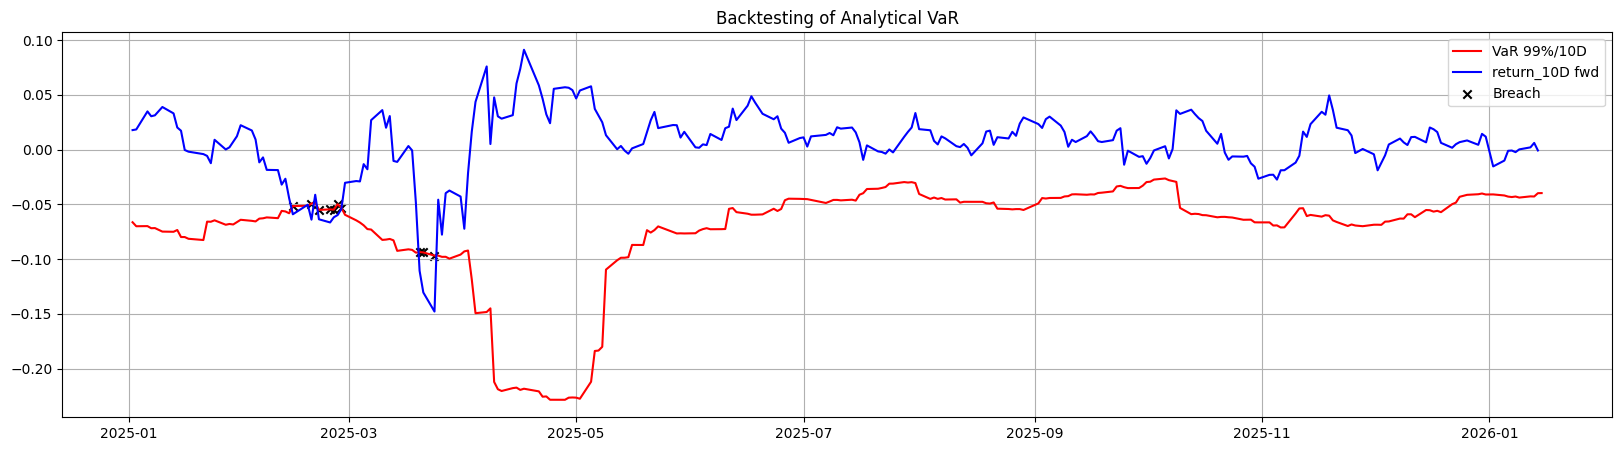

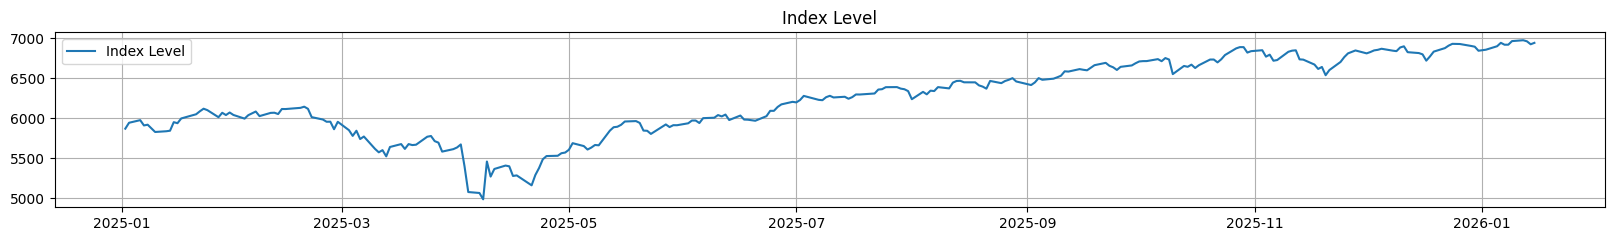

In [15]:
# Figure 1
plt.title('Backtesting of Analytical VaR')
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 20
fig_size[1] = 5
plt.rcParams["figure.figsize"] = fig_size
varPlt, = plt.plot(data.index, data['VaR'], color='RED')
r10dplt, = plt.plot(data.index, data['Forward10dReturn'], color='BLUE')
varBreachPlt = plt.scatter(data_breach.index, data_breach['VaR'], color='BLACK', marker='x')
plt.legend(["VaR 99%/10D","return_10D fwd","Breach"])
plt.grid()

# Figure 2
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax1.set_title('Index Level')
ax1.plot(data.index, data['^GSPC'])
ax1.legend(["Index Level"])
ax1.grid()
plt.show()

---

### Answer (c)

Based on the binomial distribution B∼Binomial(T,0.01):

- Green zone: $0≤b≤q_{0.95}​$
- Yellow zone: $q_{0.95}​<b≤q_{0.9999}$​
- Red zone: $b>q_{0.9999​}$

Our breach count 10 lies within the Yellow zone.

In [13]:
from scipy.stats import binom
q_green = binom.ppf(0.95, total_count, 0.01)
q_yellow = binom.ppf(0.9999, total_count, 0.01)
print(f'Green zone: [0 to {q_green:.0f}] breaches')
print(f'Yellow zone: ({q_green+1:.0f} to {q_yellow:.0f}] breaches')
print(f'Red zone: ({q_yellow:.0f}, max) breaches')

Green zone: [0 to 5] breaches
Yellow zone: (6 to 10] breaches
Red zone: (10, max) breaches
